### Isolation Forest Anomaly Detection

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs

In [ ]:
# Generate sample dataset
X, _ = make_blobs(n_samples=300, centers=1, cluster_std=0.5, random_state=42) #type: ignore

In [4]:
# Add some anomalies manually
rng = np.random.RandomState(42)
X_outliers = rng.uniform(low=-6, high=6, size=(20, 2))

In [5]:
# Combine normal data and anomalies
X = np.vstack([X, X_outliers])

In [6]:
# Create Isolation Forest model
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

In [7]:
# Train the model
model.fit(X)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [8]:
# Predict anomalies
predictions = model.predict(X)

In [9]:
# Convert predictions to dataframe
df = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df["Anomaly"] = predictions

In [10]:
# Separate normal and anomaly points
normal = df[df["Anomaly"] == 1]
anomaly = df[df["Anomaly"] == -1]

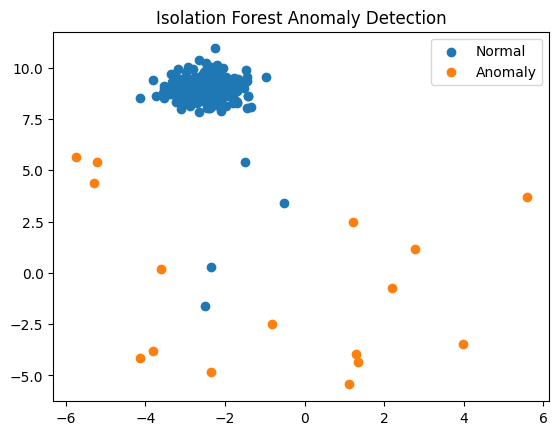

In [12]:
# Plot results
plt.scatter(normal["Feature1"], normal["Feature2"], label="Normal")
plt.scatter(anomaly["Feature1"], anomaly["Feature2"], label="Anomaly")
plt.legend()
plt.title("Isolation Forest Anomaly Detection")
plt.show()